# 🤖 Orchestrator-Worker으로 AI 팀 만들어보기 (Supervisor & Sub-agent 소통 패턴)

이번 실습에서는 **Supervisor 패턴**을 활용하여 중앙의 Supervisor 에이전트가
전문화된 Sub-agent들을 **도구(tool)로 호출**하고, Sub-agent가 결과를 Supervisor에게 보고하는
**양방향 소통 구조**를 구현합니다.

> 📢 **기존 Orchestrator-Worker vs Supervisor 패턴**
> 
> | | 기존 (Send API) | Supervisor 패턴 |
> |---|---|---|
> | **Worker 타입** | 단순 LLM 호출 | 자체 도구를 가진 Sub-agent |
> | **소통 방식** | 일방적 작업 배분 → 결과 수집 | Sub-agent ↔ Supervisor 양방향 소통 |
> | **작업 위임** | `Send()`로 정적 배분 | Supervisor가 tool call로 **동적 위임** |
> | **컨텍스트 전달** | 고정된 payload | `ToolRuntime`으로 Supervisor 전체 맥락 전달 |
> | **사람 검토** | 없음 | `HumanInTheLoopMiddleware`로 검토 가능 |

### 아키텍처: 3단 계층 구조 (3 Sub-agent)

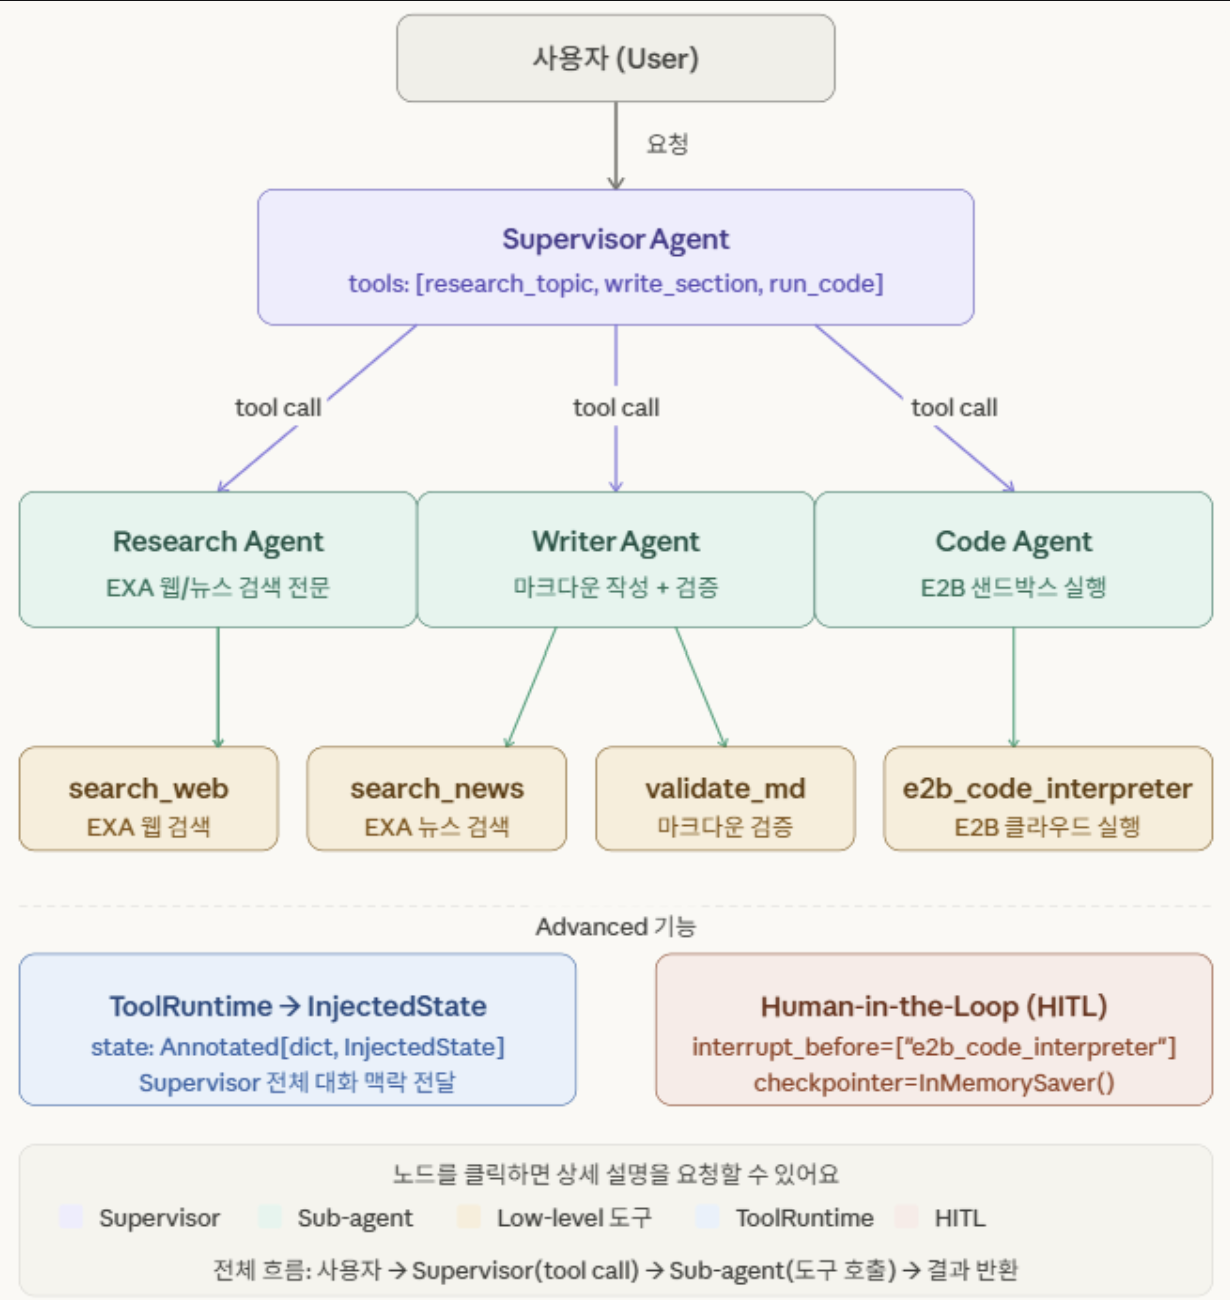

### 🎯 학습 목표
1. `create_agent()`로 전문 Sub-agent 생성하기
2. Sub-agent를 **도구(tool)**로 래핑하여 Supervisor에 제공하기
3. **EXA API**로 실시간 웹 검색 통합하기
4. **E2B 샌드박스**로 안전한 코드 실행 통합하기
5. (Advanced) `ToolRuntime`으로 Supervisor 컨텍스트를 Sub-agent에 전달하기
6. (Advanced) `HumanInTheLoopMiddleware`로 사람의 검토 추가하기

In [42]:
# pip install -qU langchain langgraph langchain-openai python-dotenv exa_py e2b-code-interpreter

In [43]:
import os
from dotenv import load_dotenv

load_dotenv()

# 필수 API 키 확인
# OPENAI API Key: LLM 호출
# EXA API KEY: 웹 검색
# E2B API KEY: 샌드박스 코드 실행

for key in ["OPENAI_API_KEY", "EXA_API_KEY", "E2B_API_KEY"]:
    assert os.getenv(key), f"{key}가 .env 파일에 설정되지 않았다."
print("필수 API 키 확인 완료")

필수 API 키 확인 완료


In [44]:
# LangSmith 추적 설정
# MultiAgent는 "Supervisor -> Sub-agent -> 도구" 호출이 중첩되어 콘솔 출력만으로는
# 실행 흐름을 파악하기 어렵다. 추적이 사실상 필수다.
# 필요한 키는 LangSmith API key 하나다 (https://smith.langchain.com -> Settings -> API Keys).
# 과거 표기(LANGCHAIN_API_KEY)로 .env에 저장했어도 같은 키이므로 아래에서 처리한다.

langsmith_key = os.getenv("LANGSMITH_API_KEY") or os.getenv("LANGCHAIN_API_KEY")
if langsmith_key:
    os.environ["LANGSMITH_API_KEY"] = langsmith_key
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = "day5-multiagent-orchestrator"
    print("LangSmith 추적 활성화 -> 프로젝트: day5-multiagent-orchestrator")
else:
    print("LANGSMITH_API_KEY 미설정 -> 추적 없이 진행한다.") 


LangSmith 추적 활성화 -> 프로젝트: day5-multiagent-orchestrator


---
## 1. Low-level 도구(Tool) 정의

이전 실습에서는 Mock 데이터를 사용했지만, 이번에는 **실제 API**를 사용합니다:

| 도구 | API | 역할 |
|------|-----|------|
| `search_web` | **EXA** | 웹 검색 (논문, 기사, 문서) |
| `search_news` | **EXA** | 최신 뉴스 검색 (날짜 필터) |
| `validate_markdown_section` | 로컬 | 마크다운 품질 검증 |
| `e2b_code_interpreter` | **E2B** | 격리된 샌드박스에서 Python 코드 실행 |

**핵심 포인트**: Sub-agent가 직접 사용하는 **low-level 도구**들입니다. Supervisor는 이 도구들을 직접 보지 않습니다.

In [45]:
from exa_py import Exa
from langchain.tools import tool
from datetime import datetime, timedelta

# EXA 클라이언트 초기화
exa_client = Exa(api_key=os.environ.get("EXA_API_KEY"))


@tool
def search_web(query: str, num_results: int = 5) -> str:
    """EXA API를 사용하여 웹 검색을 수행합니다.

    최신 연구 동향, 기술 정보, 논문, 문서 등을 검색할 때 사용하세요.

    Args:
        query: 검색할 쿼리
        num_results: 반환할 결과 수 (기본값: 5)
    """
    try:
        results = exa_client.search_and_contents(
            query=query,
            type="auto",
            num_results=num_results,
            text={"max_characters": 2000},
        )

        if not results.results:
            return f"'{query}'에 대한 검색 결과가 없습니다."

        output = []
        for i, result in enumerate(results.results, 1):
            output.append(f"{i}. **{result.title}**")
            output.append(f"   URL: {result.url}")
            if result.text:
                snippet = result.text[:500] + "..." if len(result.text) > 500 else result.text
                output.append(f"   {snippet}")
            output.append("")

        return "\n".join(output)

    except Exception as e:
        return f"검색 오류: {str(e)}"


@tool
def search_news(query: str, days: int = 7) -> str:
    """EXA API를 사용하여 최신 뉴스를 검색합니다.

    최근 뉴스, 트렌드, 업계 동향을 파악할 때 사용하세요.

    Args:
        query: 검색할 뉴스 주제
        days: 검색할 기간 (기본값: 최근 7일)
    """
    try:
        start_date = (datetime.now() - timedelta(days=days)).strftime("%Y-%m-%d")

        results = exa_client.search_and_contents(
            query=query,
            type="auto",
            num_results=5,
            start_published_date=start_date,
            text={"max_characters": 2000},
        )

        if not results.results:
            return f"최근 {days}일 내 '{query}' 관련 뉴스가 없습니다."

        output = [f"최근 {days}일 뉴스 ('{query}'):\n"]
        for i, result in enumerate(results.results, 1):
            output.append(f"{i}. **{result.title}**")
            output.append(f"   URL: {result.url}")
            if hasattr(result, 'published_date') and result.published_date:
                output.append(f"   발행일: {result.published_date}")
            if result.text:
                snippet = result.text[:500] + "..." if len(result.text) > 500 else result.text
                output.append(f"   {snippet}")
            output.append("")

        return "\n".join(output)

    except Exception as e:
        return f"뉴스 검색 오류: {str(e)}"


print("✅ EXA 검색 도구 정의 완료!")
print("   - search_web: 웹 검색 (논문, 기사, 문서)")
print("   - search_news: 최신 뉴스 검색 (날짜 필터)")

✅ EXA 검색 도구 정의 완료!
   - search_web: 웹 검색 (논문, 기사, 문서)
   - search_news: 최신 뉴스 검색 (날짜 필터)


In [46]:
import re
from e2b_code_interpreter import Sandbox

@tool
def validate_markdown_section(
    section_name: str,
    markdown: str,
    min_words: int = 50,
    max_words: int = 300,
) -> dict:
    """작성된 섹션의 마크다운 품질을 검증합니다.

    Returns:
        {"ok": bool, "word_count": int, "issues": list[str]}
    """
    issues: list[str] = []
    words = re.findall(r"\b\w+\b", markdown)
    wc = len(words)

    if wc < min_words:
        issues.append(f"너무 짧음: {wc} < {min_words} 단어")
    if wc > max_words:
        issues.append(f"너무 김: {wc} > {max_words} 단어")

    first_lines = "\n".join(markdown.splitlines()[:3]).strip()
    if "##" not in first_lines:
        issues.append("마크다운 제목(예: '## ...')이 상단에 없음")

    return {"ok": len(issues) == 0, "word_count": wc, "issues": issues}

# ── E2B 샌드박스 생성 ──
# timeout: 샌드박스 유지 시간 (초). 기본값 300초(5분)이므로
# 노트북 실습 중 만료되지 않도록 넉넉히 설정합니다.
# 만료 시 셀을 다시 실행하면 새 샌드박스가 생성됩니다.
sandbox = Sandbox.create(timeout = 600) # 10분

@tool
def e2b_code_interpreter(code: str) -> str:
    """E2B 클라우드 샌드박스에서 Python 코드를 실행합니다.
    
    데이터 분석, 계산, 시각화 등 코드 실행이 필요할 때 사용하세요.
    격리된 환경에서 안전하게 실행되며, matplotlib 등 라이브러리 사용 가능합니다.
    
    Args:
        code: 실행할 Python 코드
    """
    execution = sandbox.run_code(code)

    result_parts = []
    if execution.text:
        result_parts.append(execution.text)
    if execution.logs.stdout:
        stdout = "".join(execution.logs.stdout)
        if stdout.strip():
            result_parts.append(stdout.strip())
    if execution.logs.stderr:
        stderr = "".join(execution.logs.stderr)
        if stderr.strip():
            result_parts.append(f"[stderr] {stderr.strip()}")
    if execution.error:
        result_parts.append(f"Error: {execution.error.name}: {execution.error.value}")

    return "\n".join(result_parts) if result_parts else "코드가 성공적으로 실행되었습니다."


print("✅ Writer + Code 도구 정의 완료!")
print("   - validate_markdown_section: 마크다운 품질 검증")
print("   - e2b_code_interpreter: E2B 샌드박스 코드 실행")
print(f"  - E2B 샌드박스 생성됨 (timeout: 600초, id: {sandbox.sandbox_id[:8]}...)")

✅ Writer + Code 도구 정의 완료!
   - validate_markdown_section: 마크다운 품질 검증
   - e2b_code_interpreter: E2B 샌드박스 코드 실행
  - E2B 샌드박스 생성됨 (timeout: 600초, id: i4ams9mf...)


---
## 2. 전문 Sub-agent 생성

3개의 전문 Sub-agent를 `create_agent()`로 생성합니다.

| Sub-agent | 도구 | 역할 |
|-----------|------|------|
| **Research Agent** | `search_web`, `search_news` | EXA로 웹/뉴스 검색 |
| **Writer Agent** | `validate_markdown_section` | 마크다운 섹션 작성 + 검증 |
| **Code Agent** | `e2b_code_interpreter` | E2B 샌드박스에서 코드 실행 |

**핵심 포인트**:
- 각 Sub-agent는 자신만의 **도구**와 **전문 프롬프트**를 가짐
- Sub-agent 내부에서 도구 호출 → 검증 → 수정의 **자율적 루프**가 동작
- Supervisor는 Sub-agent의 내부 동작을 볼 필요 없음 (추상화)

In [47]:
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')
date_prompt = f"""
!!!! 반드시 주의 !!!!
[중요] 오늘 날짜는 반드시 {today}입니다.
절대로 이전 연도(2023/ 2024 등)가 아닌, {today} 기준으로만 분석하세요.
날짜를 임의로 유추해서 쓰지 말 것.\n"""

In [48]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

llm = ChatOpenAI(model = 'gpt-4o-mini', temperature=0)

# =====================
# 1) Research Agent: EXA 웹 검색 전문
# =====================

RESEARCH_AGENT_PROMPT = (
    "당신은 기술 리서치 전문 에이전트입니다. "
    "주어진 주제에 대해 search_web으로 관련 논문/기사/문서를 검색하고, "
    "필요하면 search_news로 최신 동향도 파악하세요. "
    "검색 결과를 종합하여 핵심 발견사항을 정리해서 응답하세요. "
    "반드시 출처(URL)와 연도를 포함하세요."
)

research_agent = create_agent(
    llm,
    tools = [search_web, search_news],
    system_prompt = date_prompt + RESEARCH_AGENT_PROMPT
)

# =====================
# 2) Writer Agent: 섹션 작성 전문
# =====================

WRITER_AGENT_RROMPT = (
    "당신은 기술 보고서 섹션 작성 전문 에이전트입니다. "
    "주어진 리서치 결과를 바탕으로 마크다운 형식의 섹션을 작성하세요. "
    "작성 후 반드시 validate_markdown_section을 호출하여 품질을 검증하세요. "
    "검증에 실패하면 수정 후 다시 검증하세요. "
    "최종 응답에는 완성된 마크다운 섹션만 포함하세요."
)

writer_agent = create_agent(
    llm,
    tools = [validate_markdown_section],
    system_prompt = WRITER_AGENT_RROMPT
)

# =====================
# 3) Code Agent: E2B 샌드박스 코드 실행 전문
# =====================

CODE_AGENT_PROMPT = (
    "당신은 데이터 분석 및 코드 실행 전문 에이전트입니다. "
    "e2b_code_interpreter를 사용하여 E2B 클라우드 샌드박스에서 Python 코드를 실행하세요. "
    "데이터 분석, 수학 계산, 시각화, 통계 등의 작업을 수행합니다. "
    "코드에서는 print()로 결과를 출력하세요. "
    "에러가 발생하면 코드를 수정하여 다시 실행하세요. "
    "최종 응답에는 분석 결과와 인사이트를 정리해서 포함하세요."
)

code_agent = create_agent(
    llm,
    tools=[e2b_code_interpreter],
    system_prompt=CODE_AGENT_PROMPT,
)

print("✅ 3개 Sub-agent 생성 완료!")
print("   - Research Agent: search_web, search_news (EXA)")
print("   - Writer Agent: validate_markdown_section")
print("   - Code Agent: e2b_code_interpreter (E2B 샌드박스)")

✅ 3개 Sub-agent 생성 완료!
   - Research Agent: search_web, search_news (EXA)
   - Writer Agent: validate_markdown_section
   - Code Agent: e2b_code_interpreter (E2B 샌드박스)


---

### 2-1. Sub-agent 개별 테스트

각 Sub-agent가 자신의 도구를 활용하여 자율적으로 동작하는지 확인합니다.

Sub-agent는 Supervisior와 무관하게 **독립적으로 테스트**할 수 있습니다. 이것이 계층 구조의 장점입니다.

In [49]:
# Research Agent 테스트 (EXA 실시간 웹 검색)
query = "LLM Scaling Laws에 대한 최신 연구 동향을 조사해주세요."

print(f"📝 Research Agent에 직접 요청: {query}")
print("=" * 60)

for step in research_agent.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()

📝 Research Agent에 직접 요청: LLM Scaling Laws에 대한 최신 연구 동향을 조사해주세요.
================================== Ai Message ==================================
Tool Calls:
  search_web (call_MfHWT2K7GvnR0ty1o8YawkTG)
 Call ID: call_MfHWT2K7GvnR0ty1o8YawkTG
  Args:
    query: LLM Scaling Laws
    num_results: 5
  search_news (call_RxScLYvjh27xPMUV7A7SJPr7)
 Call ID: call_RxScLYvjh27xPMUV7A7SJPr7
  Args:
    query: LLM Scaling Laws
    days: 30


C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:20: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(
C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:58: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(


================================= Tool Message =================================
Name: search_web

1. **[2001.08361] Scaling Laws for Neural Language Models**
   URL: https://arxiv.org/abs/2001.08361
   # Scaling Laws for Neural Language Models

arXiv (Cornell University). Published: 2020-01-23. Preprint. 1,523 citations.

## Authors

- Kaplan, Jared (Johns Hopkins University)
- Sam McCandlish (OpenAI (United States)): h-index 23; 8,162 citations
- Tom Henighan (OpenAI (United States)): h-index 18; 6,368 citations
- T. B. Brown (OpenAI (United States)): h-index 24; 7,552 citations
- Benjamin Chess (OpenAI (United States)): h-index 3; 4,585 citations
- Rewon Child (OpenAI (United States)): h-ind...

2. **Observational Scaling Laws and the Predictability of Language Model Performance**
   URL: https://proceedings.neurips.cc/paper_files/paper/2024/file/1cded4f97cf5f01a284c574110b7e3b9-Paper-Conference.pdf
   ## Observational Scaling Laws and the Predictability of Language Model Performanc

In [50]:
# Code Agent 테스트 (E2B 샌드박스에서 실행)
query = (
    "1부터 100까지 소수를 구하고, "
    "소수의 분포를 10단위 구간별로 분석해주세요. "
    "결과를 표 형태로 보여주세요."
)

print(f"📝 Code Agent에 직접 요청: {query}")
print("=" * 60)

for step in code_agent.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()

📝 Code Agent에 직접 요청: 1부터 100까지 소수를 구하고, 소수의 분포를 10단위 구간별로 분석해주세요. 결과를 표 형태로 보여주세요.
================================== Ai Message ==================================
Tool Calls:
  e2b_code_interpreter (call_feoCGqeFaMJ2fua6v8R6WDY9)
 Call ID: call_feoCGqeFaMJ2fua6v8R6WDY9
  Args:
    code: import pandas as pd
import numpy as np

# 1부터 100까지의 소수를 구하는 함수
def is_prime(n):
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# 1부터 100까지의 소수 리스트
primes = [n for n in range(1, 101) if is_prime(n)]

# 소수의 분포를 10단위 구간별로 분석
bins = np.arange(0, 101, 10)
prime_distribution = pd.cut(primes, bins=bins).value_counts().sort_index()

# 결과를 데이터프레임으로 변환
result_df = prime_distribution.reset_index()
result_df.columns = ['구간', '소수의 개수']

result_df
================================= Tool Message =================================
Name: e2b_code_interpreter

Error: ValueError: Can't clean for JSON: Interval(0, 10, closed='righ

---
## 3. Sub-agent를 Tool로 래핑 (핵심 아키텍처 단계)

이것이 Supervisor 패턴의 **핵심 아키텍처 단계**입니다.

각 Sub-agent를 Supervisor가 호출할 수 있는 **고수준 도구(tool)**로 래핑합니다.

```
Supervisor가 보는 것              Sub-agent 내부
───────────────────           ──────────────
research_topic(request)  →  Research Agent가 EXA search_web, search_news 호출
write_section(request)   →  Writer Agent가 validate_markdown_section 호출
run_code(request)        →  Code Agent가 E2B e2b_code_interpreter 호출
```

**중요**: Supervisor는 `search_web` 같은 low-level 도구를 모릅니다.
`research_topic`이라는 고수준 도구만 봅니다.

> 💡 **도구 설명(docstring)**이 Supervisor의 라우팅 결정에 핵심 역할을 합니다.
> 명확하고 구체적으로 작성하세요.

In [51]:
@tool
def research_topic(request: str) -> str:
    """주제를 리서치하여 핵심 발견사항을 정리합니다.
    
    기술 동향, 연구 결과, 최신 뉴스가 필요할 때 사용하세요.
    Sub-agent가 EXA API로 웹 검색 및 뉴스 검색을 자동으로 수행합니다.
    
    Input: 자연어 리서치 요청 (e.g., 'Transformer 아키텍처의 발전 과정 조사')
    """
    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    # Sub-agent의 최종 응답만 Supervisor에게 반환 (중간 추론/도구 호출은 숨김)
    return result["messages"][-1].content


@tool
def write_section(request: str) -> str:
    """리서치된 결과를 바탕으로 보고서 섹션을 작성합니다.

    마크다운 형식의 섹션 작성이 필요할 때 사용하세요.
    Sub-agnet가 작성 및 품질 검증을 자동으로 수행합니다.

    Input: 작성할 섹션 정보 (제목, 리서치 결과, 요구사항 포함)
    """
    result = code_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


@tool
def run_code(request: str) -> str:
    """데이터 분석이나 계산을 위해 Python 코드를 실행합니다.

    수치 분석, 통계 처리, 데이터 시각화가 필요할 때 사용하세요.
    Sub-agent가 E2B 샌드박스에서 안전하게 코드를 작성하고 실행합니다.

    Input: 자연어 분석 요청 (e.g., '연도별 논문 수 추이를 분석하고 차트 생성')
    """
    result = code_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


print("✅ Sub-agent → Tool 래핑 완료!")
print("   - research_topic → Research Agent (EXA 웹 검색)")
print("   - write_section  → Writer Agent (마크다운 작성 + 검증)")
print("   - run_code       → Code Agent (E2B 샌드박스 실행)")

✅ Sub-agent → Tool 래핑 완료!
   - research_topic → Research Agent (EXA 웹 검색)
   - write_section  → Writer Agent (마크다운 작성 + 검증)
   - run_code       → Code Agent (E2B 샌드박스 실행)


---

## 4. Supervisor Agent 생성

이제 Supervisor를 생성합니다.

Supervisor는 고수준 도구(`research_topic`, `write_section`, `run_code`)만 보고, 사용자 요청을 분석하여 적절한 Sub-agent에게 작업을 위임합니다.

복합 요청의 경우 여러 도구를 **순차적 또는 병렬로** 호출할 수 있습니다.

In [52]:
SUPERVISOR_PROMPT = (
    "당신은 기술 보고서 작성을 총괄하는 Supervisor 에이전트입니다. "
    "사용자의 요청을 분석하여 적절한 도구를 호출하세요: \n\n"
    "1. research_topic: 주제 리서치가 필요할 떄 (EXA 웹 검색)\n"
    "2. write_section: 리서치 결과를 바탕으로 섹션 작성할 때\n"
    "3. run_code: 데이터 분석, 계산, 시각화가 필요할 때 (E2B 샌드박스)\n\n"
    "복합 요청의 경우, 먼저 리서치를 하고 필요시 코드 분석 한 후, "
    "그 결과를 바탕으로 섹션을 작성하세요. "
    "최종 응답에서 전체 결과를 종합하여 사용자에게 보고하세요."
)

supervisor= create_agent(
    llm,
    tools = [research_topic, write_section, run_code],
    system_prompt = SUPERVISOR_PROMPT    
)

print("✅ Supervisor Agent 생성 완료!")

✅ Supervisor Agent 생성 완료!


---
## 5. Supervisor 실행 및 테스트

### 테스트 1: 단일 도메인 요청 (리서치만)

Supervisor가 요청을 분석하여 적절한 Sub-agent에게 위임하는지 확인합니다.

In [53]:
query = "최근 LLM Agent 프레임워크 동향에 대해 조사해주세요."

print(f"💬 사용자 요청: {query}")
print("=" * 60)

for step in supervisor.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()


💬 사용자 요청: 최근 LLM Agent 프레임워크 동향에 대해 조사해주세요.
================================== Ai Message ==================================
Tool Calls:
  research_topic (call_jq6FqcYul60UXiGTRt0hnvU8)
 Call ID: call_jq6FqcYul60UXiGTRt0hnvU8
  Args:
    request: 최근 LLM Agent 프레임워크 동향


C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:20: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(
C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:58: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(


================================= Tool Message =================================
Name: research_topic

최근 LLM(대형 언어 모델) 에이전트 프레임워크의 동향은 다음과 같습니다:

1. **프레임워크 통합 및 프로토콜 성숙**:
   - 2026년 7월, AI 에이전트 생태계는 Microsoft의 에이전트 프레임워크가 AutoGen과 Semantic Kernel을 흡수하면서 프레임워크 통합이 이루어졌습니다. A2A v1.0은 150개 이상의 생산 환경에서 사용되고 있습니다. (출처: [AgentScout](https://agentscout.live/tech/ai-agents/insight/20260712-ai-agent-ecosystem-w28-framework-consolidation-protocol-convergence-gateway-control-plane/), 2026)

2. **에이전틱 AI 아키텍처의 발전**:
   - 2026년 중반, 에이전틱 AI 아키텍처는 복잡한 외부 오케스트레이션 프레임워크에서 벗어나고 있으며, 다중 에이전트 스웜의 부상과 도구 프로토콜의 표준화가 이루어지고 있습니다. (출처: [MachineLearningMastery](https://machinelearningmastery.com/the-current-state-of-agentic-ai/), 2026)

3. **Dapr Agents v1.0 출시**:
   - Dapr Agents는 LLM 기반의 자율 에이전트 애플리케이션을 구축하기 위한 Python 프레임워크로, 안정적인 API와 기업 수준의 신뢰성을 제공합니다. (출처: [Dapr Docs](https://docs.dapr.io/developing-ai/dapr-agents/), 2026)

4. **NVIDIA의 에이전트 하네스**:
   - NVIDIA는 NOOA라는 오픈 소스 객체 지향 에이전트 프레임워크를 개발하여, 에이전트를

### 테스트 2: 복합 요청 (리서치 -> 분석 -> 작성)

Supervisor가 **3개 Sub-agent를 순차적으로 조율**하는지 확인합니다.

1. Research Agent: 웹에서 정보 수집
2. Code Agent: 수집된 데이터 분석
3. Writer Agent: 결과를 보고서 섹션으로 작성

In [54]:
query = (
    "LLM Scaling Laws에 대해 웹에서 리서치한 후, "
    "2025년과 2026년에 발표된 주요 모델들의 파라미터 수나 다양한 벤치마크 성적 등을 코드로 비교 분석하고, "
    "그 결과를 바탕으로 '2025년 이후 Scaling Laws의 현황' 보고서 섹션을 작성해주세요."
)

print(f"💬 사용자 요청: {query}")
print("=" * 60)

for step in supervisor.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()

💬 사용자 요청: LLM Scaling Laws에 대해 웹에서 리서치한 후, 2025년과 2026년에 발표된 주요 모델들의 파라미터 수나 다양한 벤치마크 성적 등을 코드로 비교 분석하고, 그 결과를 바탕으로 '2025년 이후 Scaling Laws의 현황' 보고서 섹션을 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  research_topic (call_7hArgrIaMVOEY611THhjsiT3)
 Call ID: call_7hArgrIaMVOEY611THhjsiT3
  Args:
    request: LLM Scaling Laws에 대한 최신 연구 및 동향 조사


C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:20: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(
C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:58: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(


================================= Tool Message =================================
Name: research_topic

### LLM Scaling Laws: 최신 연구 및 동향

#### 1. 주요 연구 결과

- **Scaling Laws for Neural Language Models** (2020)
  - **저자**: Jared Kaplan 외
  - **요약**: 이 연구는 신경 언어 모델의 성능이 모델 크기, 데이터 양, 계산량에 따라 어떻게 변화하는지를 설명하는 스케일링 법칙을 제시합니다. 이 법칙은 대규모 언어 모델의 성능 예측에 중요한 역할을 합니다.
  - **출처**: [arXiv](https://arxiv.org/abs/2001.08361) (2020)

- **Observational Scaling Laws and the Predictability of Language Model Performance** (2024)
  - **저자**: Yangjun Ruan 외
  - **요약**: 이 연구는 언어 모델의 성능이 스케일에 따라 어떻게 변하는지를 이해하는 데 중점을 두며, 스케일링 법칙이 성능 예측에 미치는 영향을 분석합니다.
  - **출처**: [NeurIPS](https://proceedings.neurips.cc/paper_files/paper/2024/file/1cded4f97cf5f01a284c574110b7e3b9-Paper-Conference.pdf) (2024)

- **Predictable Scale (Part II) — Farseer: A Refined Scaling Law in LLMs** (2025)
  - **저자**: Houyi Li 외
  - **요약**: 이 연구는 LLM의 스케일링 법칙을 정제하여 성능 예측의 정확성을 높이는 방법을 제시합니다.
  - **출처**: [NIPS](https://papers.nips.cc/paper_files/

---
## LangSmith에서 확인할 것 — MultiAgent 관찰 포인트

위 테스트 실행 후 https://smith.langchain.com 의 `day5-multiagent-orchestrator` 프로젝트에서 Trace를 열고 다음을 확인한다. 콘솔 출력으로는 보이지 않는 것들이다.

### 1. 호출 계층 (위임 구조)

Trace 트리에서 `supervisor → research_topic → research_agent → exa_web_search`처럼 중첩된 계층이 보인다.
Supervisor가 실제로 위임했는지, 아니면 자체 지식으로 답해버렸는지가 여기서 판별된다.

### 2. 라우팅 판단 근거

Supervisor의 각 도구 호출을 클릭해 **input(request)**을 확인한다.
사용자 요청이 Sub-agent에게 어떤 지시문으로 변환되어 전달됐는가? 지시문이 부실하면 SUPERVISOR_PROMPT를 수정할 근거가 된다.

### 3. Sub-agent 내부 동작

각 Worker의 ReAct 루프가 몇 번 돌았는지, EXA에 어떤 검색 쿼리를 보냈는지, E2B에서 어떤 코드가 실행됐는지 확인한다.
Worker가 도구 없이 답했다면 그 이유(프롬프트, 도구 설명)를 점검한다.

### 4. 정보 전달 손실 (Handoff)

Worker의 출력(output)이 Supervisor에게 돌아간 뒤 **최종 답변에 얼마나 반영됐는지** 비교한다.
리서치 결과가 풍부한데 최종 보고서가 빈약하다면 손실 지점이 Supervisor 종합 단계라는 뜻이다.

### 5. 비용과 병목

Trace 상단의 토큰·시간 합계와 각 하위 run의 비중을 본다.
MultiAgent는 LLM 호출이 곱으로 늘어난다 — 어느 에이전트가 비용/시간의 대부분을 쓰는지 파악하면 모델 교체(예: Worker만 저가 모델) 판단이 가능하다.

### 6. 오류와 중단 지점

실패한 run은 빨간색으로 표시된다. 도구 호출 실패가 Supervisor 레벨인지 Worker 레벨인지 즉시 구분된다.
아래 Human-in-the-Loop 실습에서는 interrupt로 **대기 중인 상태**가 Trace에 어떻게 남는지도 관찰한다.

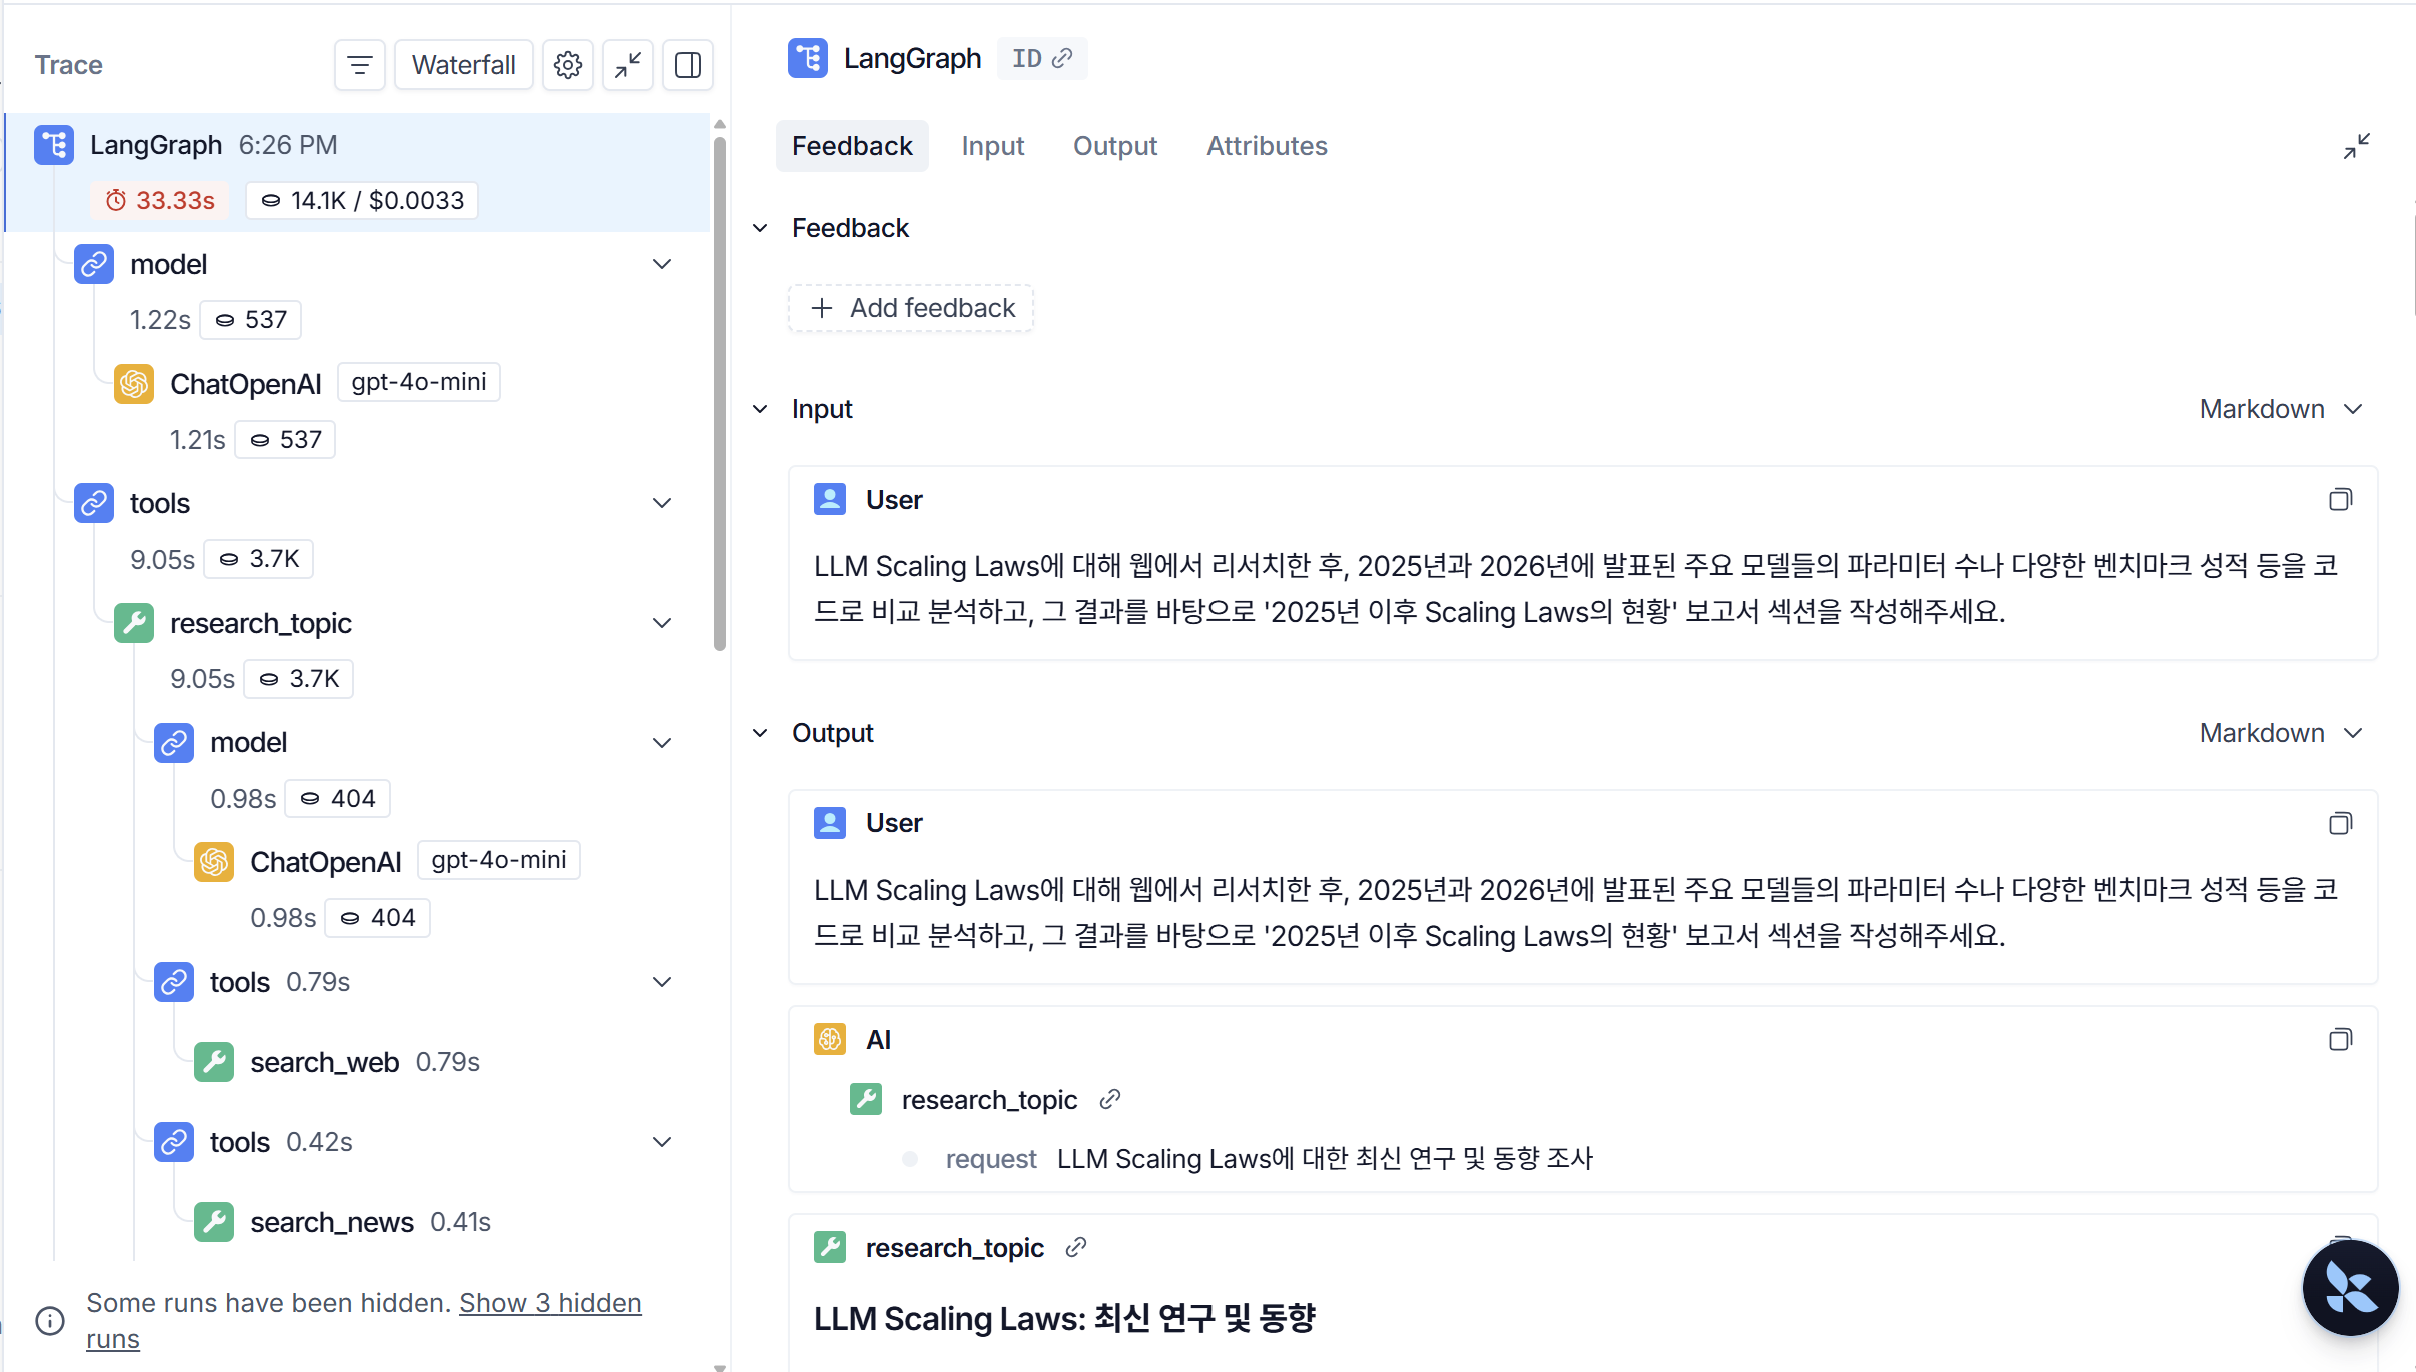

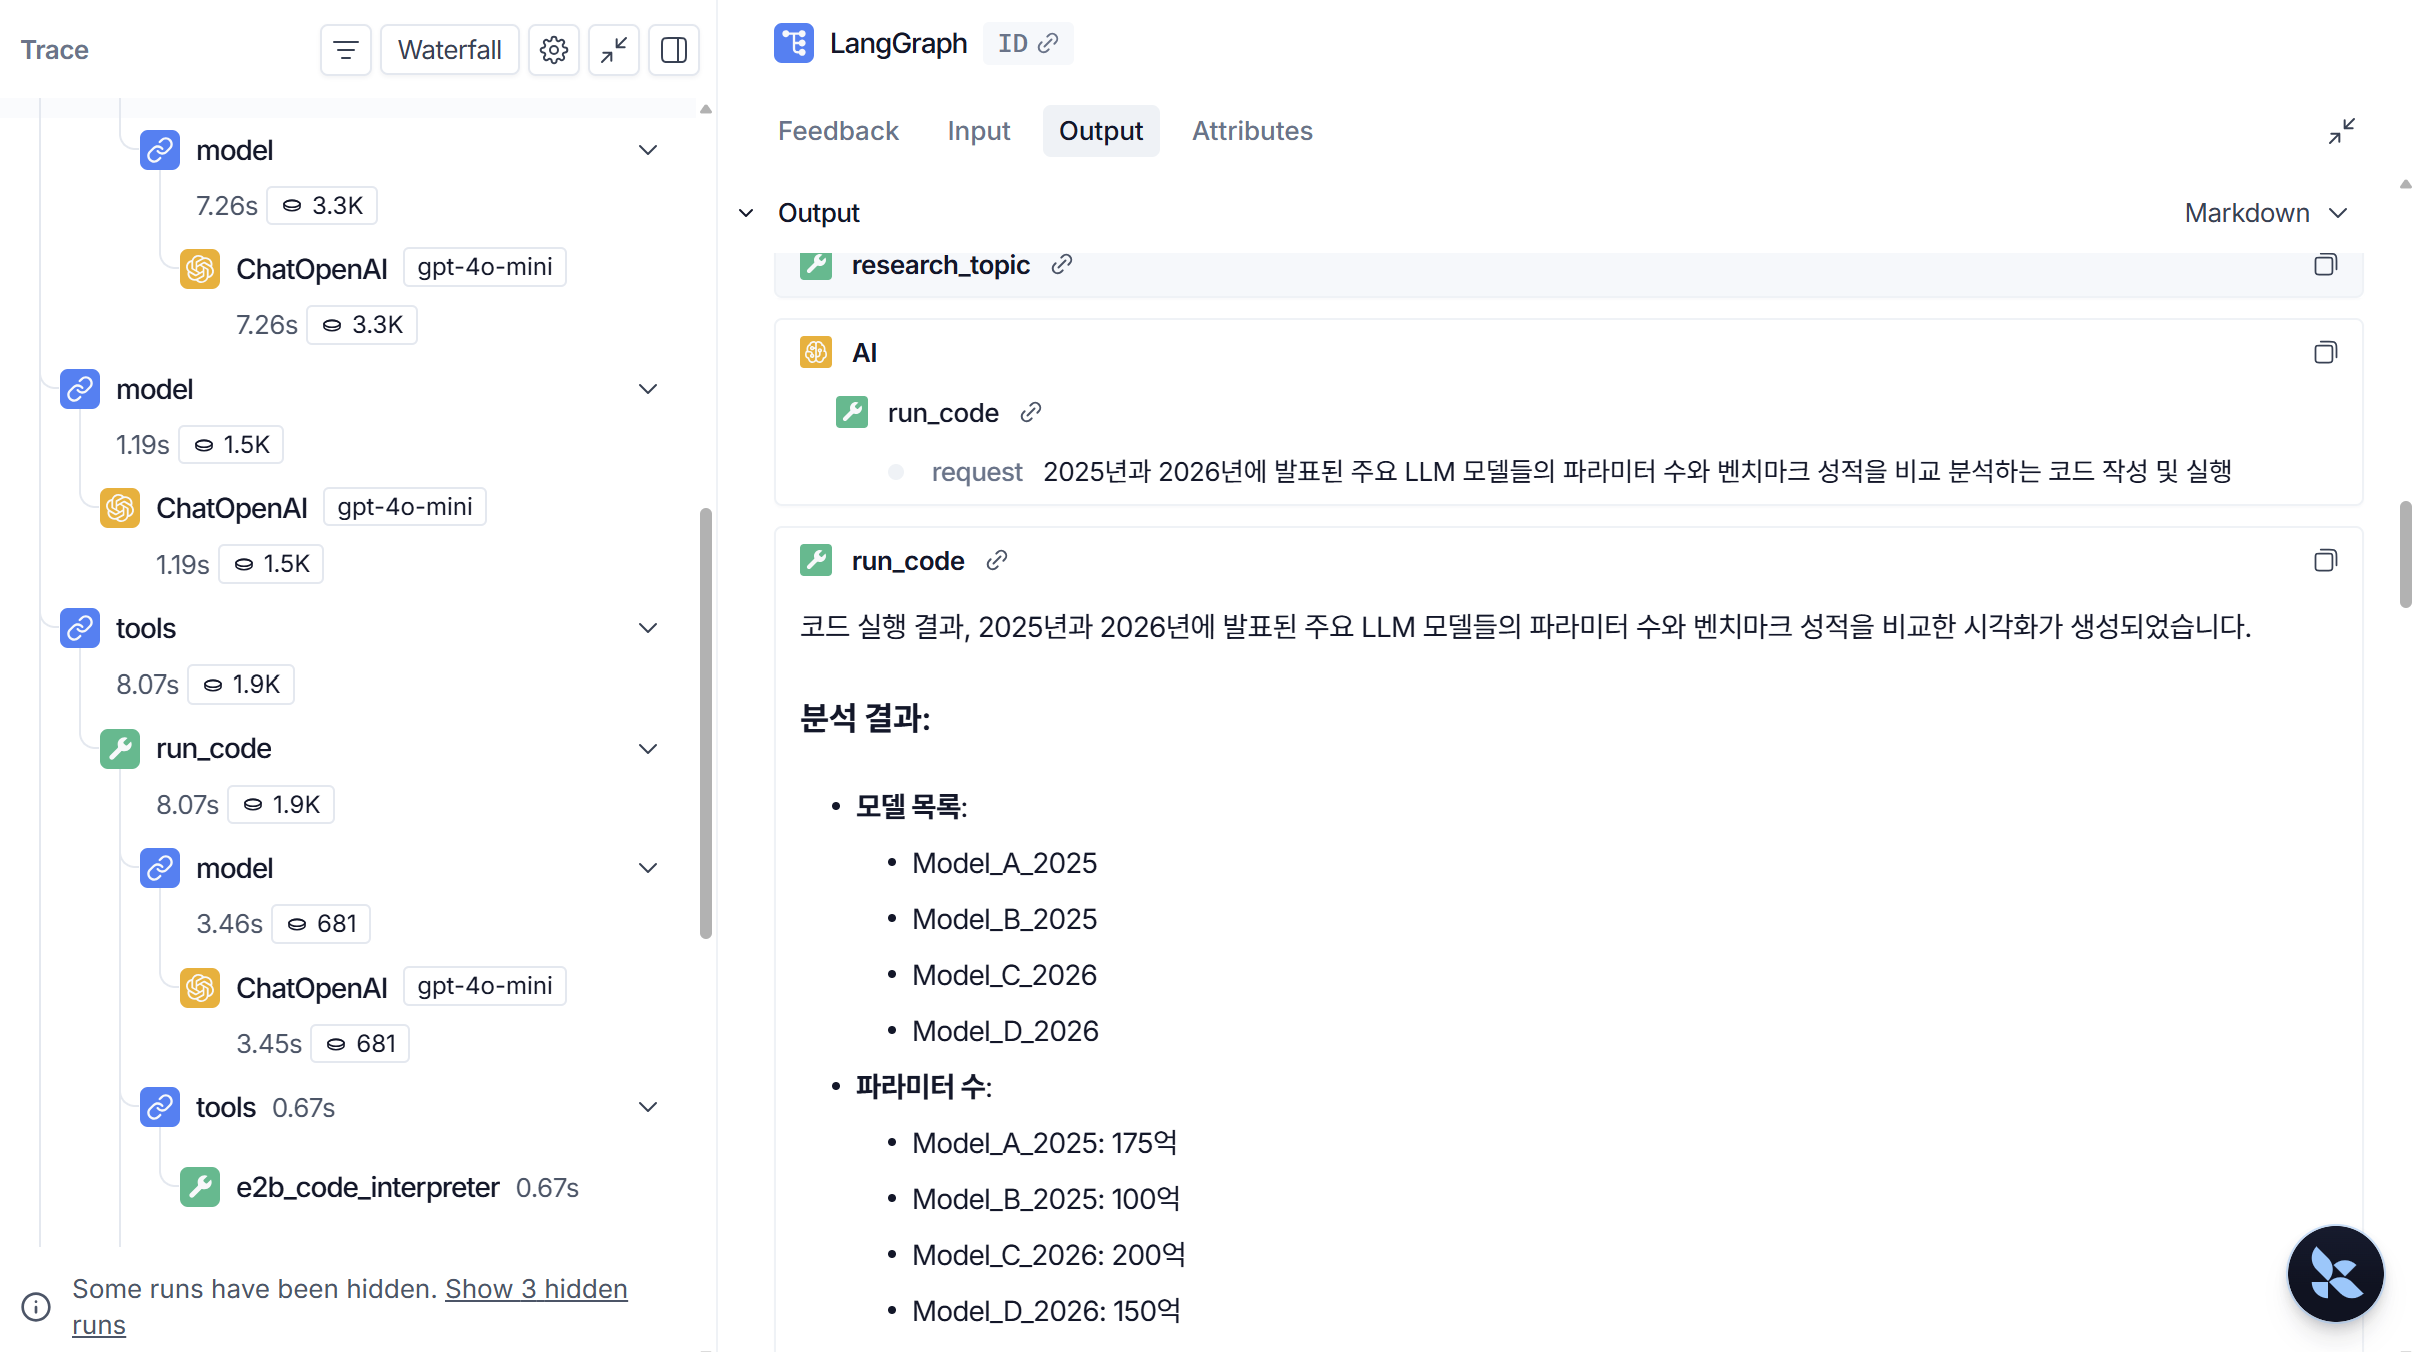

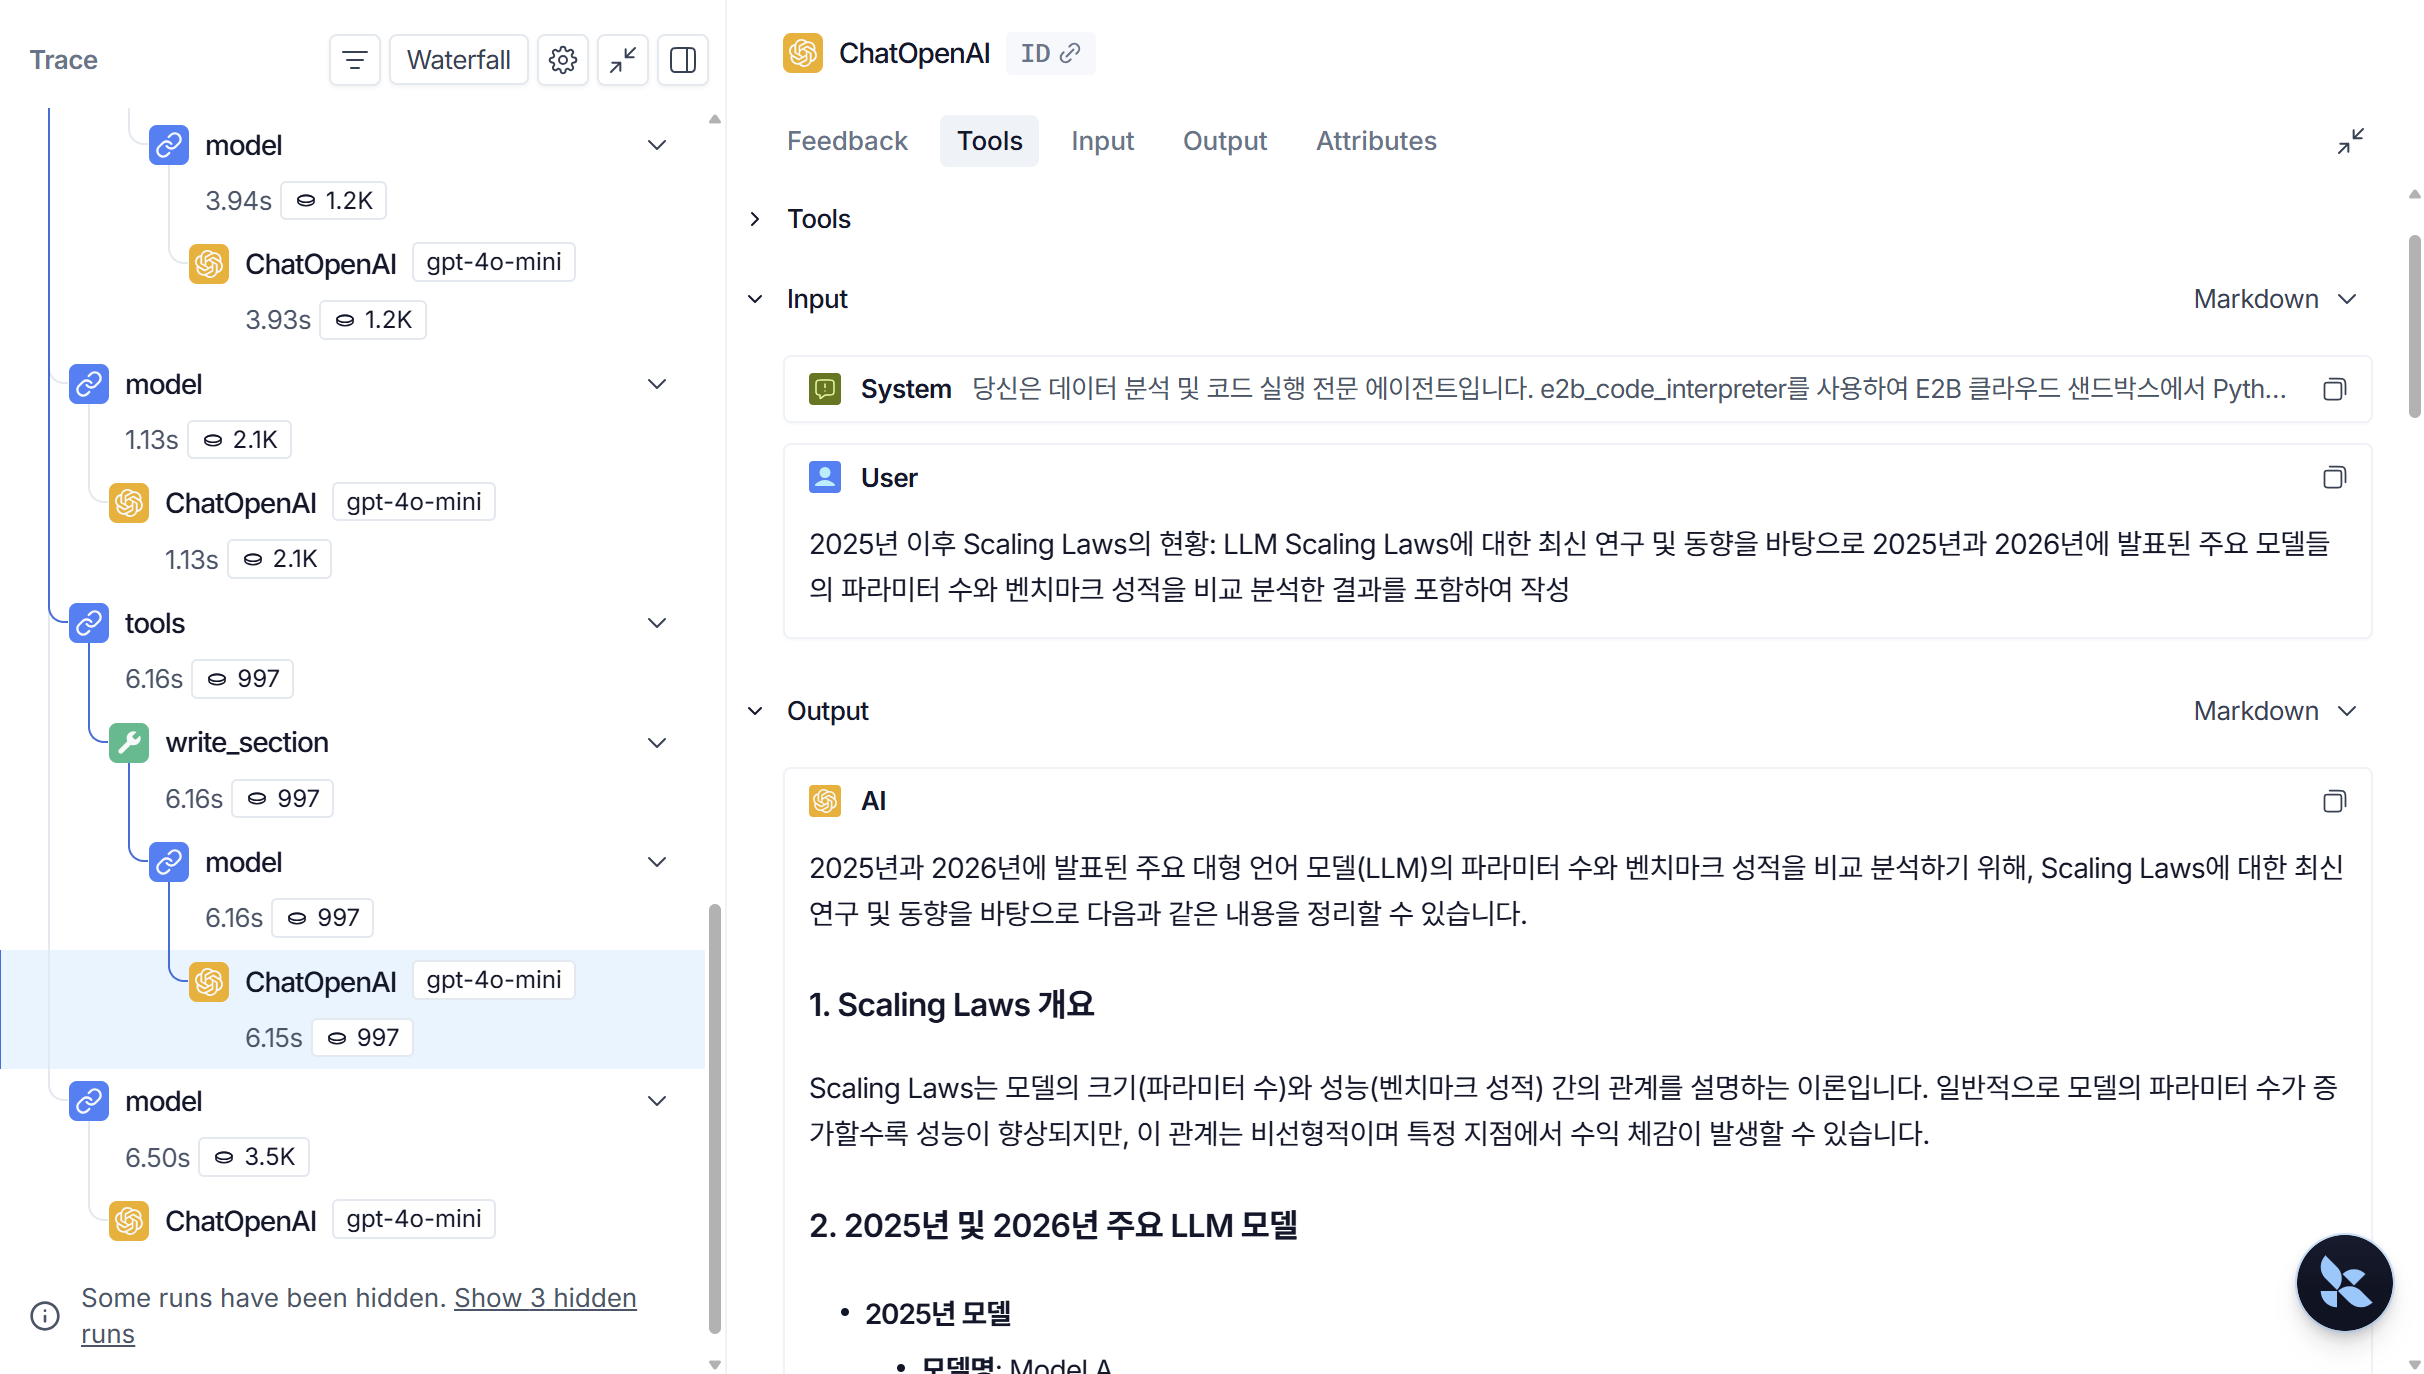

---
## 6. (Advanced) ToolRuntime으로 Supervisor 컨텍스트 전달

기본적으로 Sub-agent는 Supervisor가 전달한 request 문자열만 받습니다.

ToolRuntime을 사용하면 **Supervisor의 전체 대화 맥락**을 Sub-agent에게 전달할 수 있습니다.

예: 사용자가 "대상 독자는 AI 엔지니어" 같은 맥락을 제공한 경우, Sub-agent가 이 맥락을 참조하여 더 적절한 결과를 생성합니다.

```python
@tool
def my_tool(request: str, runtime: ToolRuntime) -> str:
    # runtime,state["messages"] -> Supervisor의 전체 대화 기록 접근 가능
    original_user_msg = next(
        m for m in runtime.state["messages"] if m.type == "human"
    )

```

In [55]:
from langchain.tools import InjectedState
from typing import Annotated


@tool
def research_topic_with_context(
    request: str,
    state: Annotated[dict, InjectedState],
) -> str:
    """Supervisor의 전체 대화 맥락을 포함하여 리서치합니다."""
    original_user_message = next(
        (m for m in state["messages"] if m.type == "human"),
        None,
    )
    supervisor_context = (
        original_user_message.content if original_user_message else ""
    )

    enriched_prompt = (
        f"[Supervisor 전체 맥락]\n{supervisor_context}\n\n"
        f"[현재 리서치 요청]\n{request}"
    )

    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": enriched_prompt}]}
    )
    return result["messages"][-1].content


@tool
def write_section_with_context(
    request: str,
    state: Annotated[dict, InjectedState],
) -> str:
    """Supervisor의 전체 대화 맥락을 포함하여 섹션을 작성합니다."""
    original_user_message = next(
        (m for m in state["messages"] if m.type == "human"),
        None,
    )
    supervisor_context = (
        original_user_message.content if original_user_message else ""
    )

    enriched_prompt = (
        f"[Supervisor 전체 맥락]\n{supervisor_context}\n\n"
        f"[현재 작성 요청]\n{request}"
    )

    result = writer_agent.invoke(
        {"messages": [{"role": "user", "content": enriched_prompt}]}
    )
    return result["messages"][-1].content


@tool
def run_code_with_context(
    request: str,
    state: Annotated[dict, InjectedState],
) -> str:
    """Supervisor의 전체 대화 맥락을 포함하여 코드를 실행합니다."""
    original_user_message = next(
        (m for m in state["messages"] if m.type == "human"),
        None,
    )
    supervisor_context = (
        original_user_message.content if original_user_message else ""
    )

    enriched_prompt = (
        f"[Supervisor 전체 맥락]\n{supervisor_context}\n\n"
        f"[현재 분석 요청]\n{request}"
    )

    result = code_agent.invoke(
        {"messages": [{"role": "user", "content": enriched_prompt}]}
    )
    return result["messages"][-1].content


# ToolRuntime 버전 Supervisor
supervisor_with_context = create_agent(
    llm,
    tools=[
        research_topic_with_context,
        write_section_with_context,
        run_code_with_context,
    ],
    system_prompt=SUPERVISOR_PROMPT,
)

print("✅ ToolRuntime 버전 Supervisor 생성 완료!")
print("   Sub-agent가 Supervisor의 전체 대화 맥락을 참조할 수 있습니다.")

✅ ToolRuntime 버전 Supervisor 생성 완료!
   Sub-agent가 Supervisor의 전체 대화 맥락을 참조할 수 있습니다.


In [56]:
# ToolRuntime 테스트: "대상 독자", "관점" 같은 맥락이 Sub-agent에 전달됨
query = (
    "LLM Scaling Laws에 대한 기술 보고서를 작성하려고 합니다. "
    "대상 독자는 AI 엔지니어이고, 실무 적용 관점을 강조해주세요. "
    "먼저 Scaling Laws에 대해 웹에서 조사한 후, '핵심 원리' 섹션을 작성해주세요."
)

print(f"💬 사용자 요청: {query}")
print("=" * 60)

for step in supervisor_with_context.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()

💬 사용자 요청: LLM Scaling Laws에 대한 기술 보고서를 작성하려고 합니다. 대상 독자는 AI 엔지니어이고, 실무 적용 관점을 강조해주세요. 먼저 Scaling Laws에 대해 웹에서 조사한 후, '핵심 원리' 섹션을 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  research_topic_with_context (call_6U29dg7mVDywBp2pwQeJW9aC)
 Call ID: call_6U29dg7mVDywBp2pwQeJW9aC
  Args:
    request: LLM Scaling Laws에 대한 정보 조사


C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:20: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(


================================= Tool Message =================================
Name: research_topic_with_context

### LLM Scaling Laws: 핵심 원리

LLM(대형 언어 모델) 스케일링 법칙은 모델의 성능이 데이터와 파라미터 수의 증가에 따라 어떻게 변화하는지를 설명하는 수학적 원리입니다. 이 법칙은 AI 엔지니어들이 모델을 설계하고 최적화하는 데 중요한 통찰을 제공합니다. 다음은 LLM 스케일링 법칙의 핵심 원리입니다.

1. **성능과 스케일의 관계**: LLM의 성능은 모델의 크기(파라미터 수)와 훈련 데이터의 양에 비례하여 증가합니다. 즉, 더 많은 파라미터와 더 많은 데이터로 훈련된 모델은 일반적으로 더 나은 성능을 보입니다. Kaplan et al. (2020)에서는 이러한 관계를 수학적으로 모델링하여, 성능이 로그 스케일에서 선형적으로 증가함을 보여주었습니다.

2. **비용 효율성**: 스케일링 법칙은 모델의 성능을 극대화하기 위해 필요한 자원(시간, 비용 등)을 예측하는 데 유용합니다. 예를 들어, 특정 성능 목표를 달성하기 위해 필요한 데이터와 파라미터 수를 계산할 수 있습니다. 이는 AI 엔지니어들이 예산과 자원을 효율적으로 배분하는 데 도움을 줍니다.

3. **최적의 하이퍼파라미터 설정**: 스케일링 법칙은 하이퍼파라미터 조정에도 적용됩니다. 모델의 크기와 데이터 양에 따라 최적의 학습률, 배치 크기 등을 조정할 수 있으며, 이는 훈련 과정의 안정성과 성능을 향상시킵니다. Li et al. (2025)에서는 이러한 하이퍼파라미터의 최적화에 대한 구체적인 방법론을 제시하고 있습니다.

4. **예측 가능성**: 스케일링 법칙은 모델 성능의 예측 가능성을 높입니다. 이는 새로운 모델을 설계할 때, 과거의 데이터와 성능을 기반으로 미래의 성능을 예측할 수 있게 해줍니다. Ruan et al. (2024)에서는 이러한 예측 가능성을 활용하

---
## 7. (Advanced) Human-in-the-loop 리뷰

중요한 작업(외부 API 호출, 코드 실행 등)에 **사람의 승인**을 추가할 수 있습니다.

`HumanInTheLoopMiddleware`를 사용하면:
- 특정 도구 호출 전에 **실행을 일시 중지** (interrupt)
- 사용자가 **승인(approve)**, **수정(edit)**, **거부(reject)** 가능
- 승인 후 실행 재개

> ⚠️ `checkpointer`가 **최상위 에이전트(Supervisor)에만** 필요합니다.
> 실행 일시중지/재개를 위한 상태 저장에 사용됩니다.

In [57]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

# Code Agent에 HITL 추가 - 코드 실행 전에 사람이 검토
code_agent_with_review = create_agent(
    llm,
    tools=[e2b_code_interpreter],
    system_prompt=CODE_AGENT_PROMPT,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"e2b_code_interpreter": True},
            description_prefix="코드 실행 전 사람의 검토 필요",
        ),
    ],
)


@tool
def run_code_reviewed(request: str) -> str:
    """사람의 검토를 거쳐 코드를 실행합니다."""
    result = code_agent_with_review.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


# Supervisor (checkpointer 필수 - 실행 일시중지/재개에 필요)
supervisor_with_hitl = create_agent(
    llm,
    tools=[research_topic, write_section, run_code_reviewed],
    system_prompt=SUPERVISOR_PROMPT,
    checkpointer=InMemorySaver(),
)

print("✅ Human-in-the-loop Supervisor 생성 완료!")

✅ Human-in-the-loop Supervisor 생성 완료!


In [58]:
query = "GPT-4와 LLaMA 3의 파라미터 수를 비교하는 코드를 실행해주세요"
config = {"configurable": {"thread_id": "hitl-demo-1"}}

print(f"💬 사용자 요청: {query}")
print("=" * 60)

interrupts = []
for step in supervisor_with_hitl.stream(
    {"messages": [{"role": "user", "content": query}]},
    config,
):
    for update in step.values():
        if isinstance(update, dict):
            for message in update.get("messages", []):
                message.pretty_print()
        else:
            interrupt_ = update[0]
            interrupts.append(interrupt_)
            print(f"\n⏸️ INTERRUPTED: {interrupt_.id}")
            for req in interrupt_.value.get("action_requests", []):
                print(f"   {req.get('description', '')[:200]}")

💬 사용자 요청: GPT-4와 LLaMA 3의 파라미터 수를 비교하는 코드를 실행해주세요
================================== Ai Message ==================================
Tool Calls:
  run_code_reviewed (call_41RwSLFKsp3p8tppK46PG9nE)
 Call ID: call_41RwSLFKsp3p8tppK46PG9nE
  Args:
    request: # 파라미터 수 비교를 위한 코드
# GPT-4와 LLaMA 3의 파라미터 수를 정의합니다.

# 모델의 파라미터 수 (단위: 억)
parameters = {
    'GPT-4': 175,  # GPT-4의 파라미터 수
    'LLaMA 3': 70   # LLaMA 3의 파라미터 수
}

# 파라미터 수 비교
for model, count in parameters.items():
    print(f'{model}의 파라미터 수: {count}억')

# 파라미터 수 차이 계산
gpt4_params = parameters['GPT-4']
llama3_params = parameters['LLaMA 3']

difference = gpt4_params - llama3_params
print(f'GPT-4와 LLaMA 3의 파라미터 수 차이: {difference}억')

⏸️ INTERRUPTED: 5604553f3ba4d5f1f303db7cf54b6618
   코드 실행 전 사람의 검토 필요

Tool: e2b_code_interpreter
Args: {'code': "# 모델의 파라미터 수 (단위: 억)\nparameters = {\n    'GPT-4': 175,  # GPT-4의 파라미터 수\n    'LLaMA 3': 70   # LLaMA 3의 파라미터 수\n}\n\n# 파라미터 수 비교\nfor mod


In [59]:
from langgraph.types import Command

if interrupts:
    # 모든 인터럽트 승인 (실제로는 사용자가 확인/수정/거부 결정)
    resume = {}
    for interrupt_ in interrupts:
        resume[interrupt_.id] = {"decisions": [{"type": "approve"}]}

    print("✅ 모든 작업 승인 - 실행 재개")
    print("=" * 60)

    for step in supervisor_with_hitl.stream(
        Command(resume=resume),
        config,
    ):
        for update in step.values():
            if isinstance(update, dict):
                for message in update.get("messages", []):
                    message.pretty_print()
            else:
                interrupt_ = update[0]
                interrupts.append(interrupt_)
                print(f"\n⏸️ INTERRUPTED: {interrupt_.id}")
else:
    print("인터럽트 없이 실행 완료!")

✅ 모든 작업 승인 - 실행 재개
================================= Tool Message =================================
Name: run_code_reviewed

코드 실행 결과는 다음과 같습니다:

- **GPT-4의 파라미터 수**: 175억
- **LLaMA 3의 파라미터 수**: 70억
- **GPT-4와 LLaMA 3의 파라미터 수 차이**: 105억

### 인사이트
GPT-4는 LLaMA 3에 비해 105억 개의 파라미터가 더 많습니다. 이는 GPT-4가 더 복잡하고 강력한 모델임을 나타내며, 더 많은 데이터와 학습을 통해 더 나은 성능을 발휘할 가능성이 높습니다.
================================== Ai Message ==================================

코드 실행 결과는 다음과 같습니다:

- **GPT-4의 파라미터 수**: 175억
- **LLaMA 3의 파라미터 수**: 70억
- **GPT-4와 LLaMA 3의 파라미터 수 차이**: 105억

### 인사이트
GPT-4는 LLaMA 3에 비해 105억 개의 파라미터가 더 많습니다. 이는 GPT-4가 더 복잡하고 강력한 모델임을 나타내며, 더 많은 데이터와 학습을 통해 더 나은 성능을 발휘할 가능성이 높습니다.


In [60]:
from langgraph.types import Command
import uuid

# 1. 사용자에게 직접 요청 받기
user_query = input("에이전트에게 요청할 내용을 입력하세요: ")

# 매번 새로운 대화로 실행하고 싶으면 thread_id를 새로 생성
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

print(f"\n💬 사용자 요청: {user_query}")
print("=" * 60)

# 2. 첫 실행 — 실행 도중 승인이 필요한 지점에서 자동으로 멈춤
interrupts = []
for step in supervisor_with_hitl.stream(
    {"messages": [{"role": "user", "content": user_query}]},
    config,
):
    for update in step.values():
        if isinstance(update, dict):
            for message in update.get("messages", []):
                message.pretty_print()
        else:
            interrupt_ = update[0]
            interrupts.append(interrupt_)
            print(f"\n⏸️ 승인 대기: {interrupt_.id}")
            for req in interrupt_.value.get("action_requests", []):
                print(f"   요청 내용: {req.get('description', '')[:300]}")

# 3. 멈춘 지점이 있으면, 사람에게 진짜로 승인 여부를 물어봄
while interrupts:
    resume = {}
    for interrupt_ in interrupts:
        answer = input("\n이 작업을 승인하시겠습니까? (y/n): ").strip().lower()
        if answer == "y":
            resume[interrupt_.id] = {"decisions": [{"type": "approve"}]}
            print("✅ 승인됨")
        else:
            resume[interrupt_.id] = {"decisions": [{"type": "reject"}]}
            print("❌ 거부됨")

    # 4. 승인/거부 결과를 반영해서 실행 재개
    interrupts = []
    for step in supervisor_with_hitl.stream(Command(resume=resume), config):
        for update in step.values():
            if isinstance(update, dict):
                for message in update.get("messages", []):
                    message.pretty_print()
            else:
                interrupt_ = update[0]
                interrupts.append(interrupt_)
                print(f"\n⏸️ 승인 대기: {interrupt_.id}")

print("\n" + "=" * 60)
print("✅ 전체 작업 완료!")


💬 사용자 요청: "클라우드 업계 최근 이슈를 조사하고, 관련 수치 데이터를 코드로 분석해서 표로 정리한 보고서를 작성해주세요"
================================== Ai Message ==================================
Tool Calls:
  research_topic (call_r0ghYvRjeYrin7wDtR9eDc7x)
 Call ID: call_r0ghYvRjeYrin7wDtR9eDc7x
  Args:
    request: 클라우드 업계 최근 이슈
  run_code_reviewed (call_Z4P1aQkoXSPLpDNwzXUexjlo)
 Call ID: call_Z4P1aQkoXSPLpDNwzXUexjlo
  Args:
    request: 클라우드 업계 관련 수치 데이터 분석


C:\Users\qkrru\AppData\Local\Temp\ipykernel_2524\520742472.py:58: DeprecationWarning: search_and_contents() is deprecated. Use search() instead; search() returns text contents by default.
  results = exa_client.search_and_contents(


================================= Tool Message =================================
Name: run_code_reviewed

클라우드 업계 관련 수치 데이터 분석을 위해 어떤 특정 데이터셋이나 지표를 분석하고 싶은지 알려주시면, 그에 맞는 분석을 진행할 수 있습니다. 예를 들어, 클라우드 서비스 제공업체의 매출, 시장 점유율, 사용자 수, 성장률 등의 데이터를 분석할 수 있습니다.

원하는 데이터의 종류나 특정 질문이 있다면 말씀해 주세요!
================================= Tool Message =================================
Name: research_topic

최근 클라우드 업계의 주요 이슈는 다음과 같습니다:

1. **클라우드 인프라 리스크**: 최근 클라우드 서비스의 연쇄 장애가 기업 인프라의 리스크를 드러내고 있습니다. 이러한 장애는 기업들이 클라우드 의존도를 높이면서 발생하는 문제로, 기업들은 이에 대한 대비책을 마련해야 할 필요성이 커지고 있습니다. (출처: 비즈셀미디어, 2026-08-02) [링크](https://www.bizsel-media.com/news/452676)

2. **AI 시대의 클라우드 공룡**: 아마존(AWS)과 마이크로소프트(애저)의 실적이 급증하고 있으며, 이는 AI 시대에 클라우드 인프라를 보유한 기업들이 안정적인 수익을 창출하고 있다는 것을 보여줍니다. 클라우드 사업이 없는 기업들은 투자 회수에 대한 불확실성이 커지고 있으며, 월가는 클라우드 사업 보유 여부를 AI 시대의 승자의 핵심 조건으로 보고 있습니다. (출처: 블록미디어, 2026-08-01) [링크](https://www.blockmedia.co.kr/archives/1123232)

3. **AI 수익화와 빅테크 주가**: AI 수익화가 빅테크 기업들의 주가에 큰 영향을 미치고 있습니다. 마이크로소프트, 구글, 아마존 등은 2023년

---
## 8. 정리 및 리소스 해제

In [61]:
# E2B 샌드박스 종료 (비용 절약)
sandbox.kill()
print("✅ E2B 샌드박스가 종료되었습니다.")

✅ E2B 샌드박스가 종료되었습니다.


---
## 💡 정리

### 핵심 개념 정리

| 구성요소 | 역할 | 핵심 기술 |
|---------|------|----------|
| **Low-level 도구** | 실제 API 호출 | EXA (웹 검색), E2B (코드 실행) |
| **Research Agent** | 웹/뉴스 검색 전문 | `create_agent()` + EXA `search_web`, `search_news` |
| **Writer Agent** | 보고서 섹션 작성 | `create_agent()` + `validate_markdown_section` |
| **Code Agent** | 데이터 분석/코드 실행 | `create_agent()` + E2B `e2b_code_interpreter` |
| **Tool 래핑** | Sub-agent → Supervisor 도구 | Sub-agent를 `@tool` 함수로 래핑 |
| **Supervisor** | 작업 분석 + 위임 + 결과 종합 | `create_agent()` + 고수준 도구 3개 |
| **ToolRuntime** | 맥락 전달 | `runtime.state`로 Supervisor 대화 참조 |
| **HITL** | 사람의 검토/승인 | `HumanInTheLoopMiddleware` |

### 3단 계층 아키텍처의 장점

- **관심사 분리**: 각 계층이 명확한 책임을 가짐
- **독립적 개선**: Sub-agent를 개별적으로 테스트하고 개선 가능
- **확장 용이**: 새로운 도메인(예: 차트 생성 Agent)을 기존 코드 변경 없이 추가
- **동적 위임**: Supervisor가 상황에 따라 도구를 선택적으로 호출

### 사용된 외부 서비스

| 서비스 | 용도 | 링크 |
|--------|------|------|
| **EXA** | AI-native 웹 검색 API | https://exa.ai |
| **E2B** | 클라우드 샌드박스 코드 실행 | https://e2b.dev |
